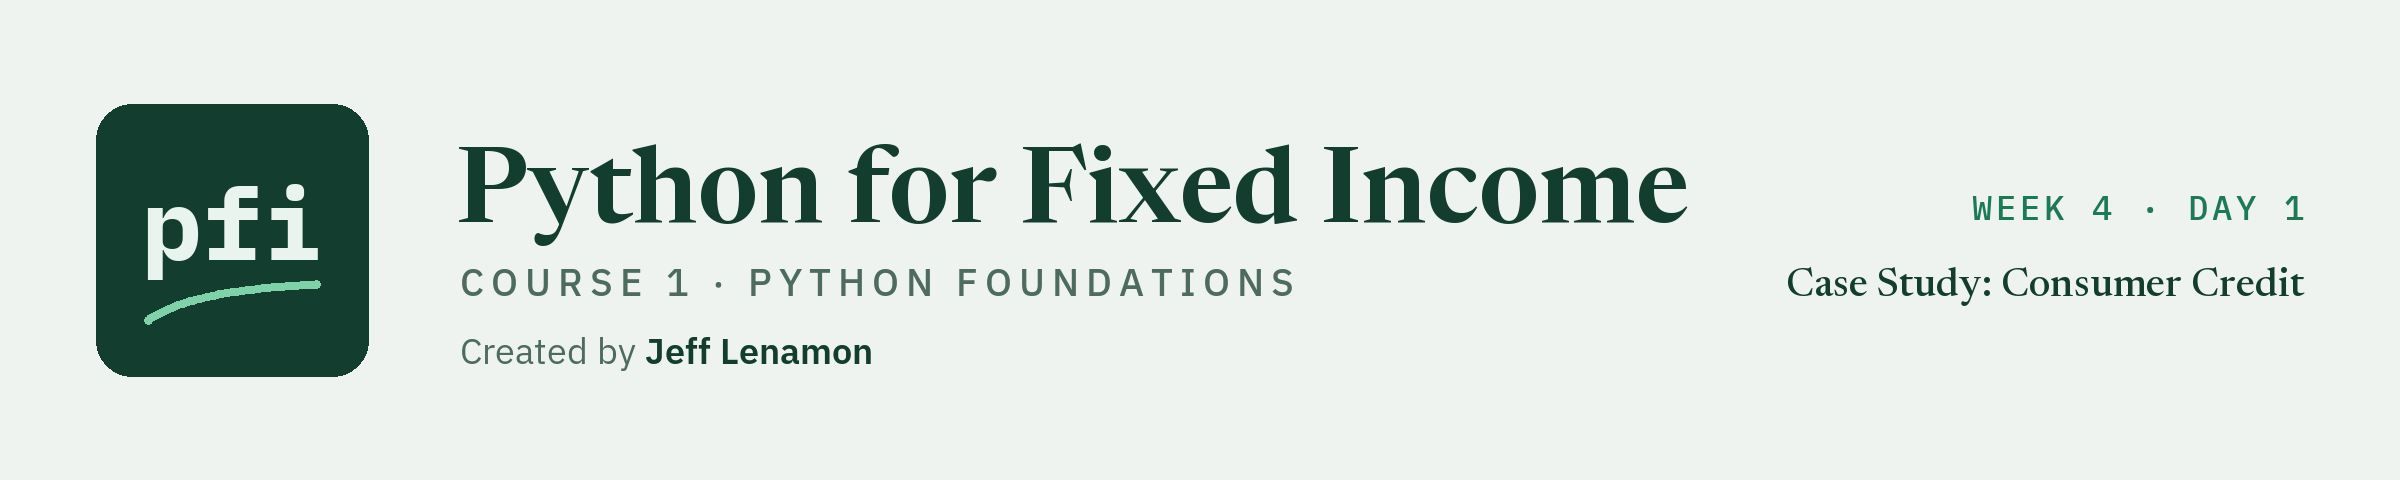

# Case Study: Consumer Credit

Week 4. A public file of 30,000 credit card accounts is checked, summarized, and charted, and what it shows about the accounts that defaulted is written up as rates with their counts.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week4/day1/16_case_study_consumer_credit.ipynb)

## Problem Definition

### Context

You are a credit analyst who covers consumer lenders. A colleague hands you a public dataset of credit card accounts and asks one question: **what does this file show about which accounts defaulted the following month?**

The answer is a description. It says what the default rate was in this file, for all accounts and for groups of accounts, with the number of accounts behind each rate. It does not say why an account defaulted, and it is not advice on lending.

### Objective

This is the first notebook of week 4. It runs the whole routine of weeks 2 and 3 on a file that is larger than any so far, 30,000 rows, and on a kind of column that is new: an outcome that is yes or no. The order is the one from notebook 13. Check the file against its documentation, look at the outcome, then one column at a time, then the outcome against one column, then against two, then build new columns, and write up what was found.

### Where the data comes from

Today's data is real. It is not synthetic, and it is the first file in the course that describes people. It is published by the UCI Machine Learning Repository under a license that allows sharing and adaptation with credit.

| | |
| --- | --- |
| Title | Default of Credit Card Clients |
| Creator | I-Cheng Yeh |
| Source | UCI Machine Learning Repository, https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients |
| DOI | https://doi.org/10.24432/C55S3H |
| License | Creative Commons Attribution 4.0 International (CC BY 4.0), https://creativecommons.org/licenses/by/4.0/legalcode |
| Citation, as the page gives it | Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H. |
| Changes made for this course | The original is an Excel file with two header rows. The first, which holds the labels X1 to X23 and Y, was dropped, and the sheet was saved as `credit_card_default.csv`. Nothing else was changed: all 30,000 rows and 25 columns are there with their original names and values. |

The dataset page describes the data as being about "customers' default payments in Taiwan", with monthly payment records "from April to September, 2005". That is all it says about place and period. The page does not name the lender or say how the accounts were chosen. So the file is one set of credit card accounts, in Taiwan, in 2005. Consumer credit markets differ from one country and one period to another, including from US credit, and nothing found here carries over to another market.

### The columns

Every meaning in this table is taken from the dataset page. Amounts are in **New Taiwan dollars**, which the page writes as "NT dollar". This notebook writes NT dollars throughout.

| Column | Meaning, from the dataset page | Units or codes |
| --- | --- | --- |
| `ID` | the row's identifier | whole number |
| `LIMIT_BAL` | "Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit." This notebook calls it the credit limit. | NT dollars |
| `SEX` | "Gender (1 = male; 2 = female)" | code |
| `EDUCATION` | "Education (1 = graduate school; 2 = university; 3 = high school; 4 = others)" | code |
| `MARRIAGE` | "Marital status (1 = married; 2 = single; 3 = others)" | code |
| `AGE` | "Age (year)" | years |
| `PAY_0`, `PAY_2` to `PAY_6` | the repayment status in each of six months. `PAY_0` is September 2005, `PAY_2` is August, and so on back to `PAY_6`, April. "-1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above." | code |
| `BILL_AMT1` to `BILL_AMT6` | "Amount of bill statement (NT dollar)". `BILL_AMT1` is September 2005, back to `BILL_AMT6`, April. | NT dollars |
| `PAY_AMT1` to `PAY_AMT6` | "Amount of previous payment (NT dollar)". `PAY_AMT1` is the "amount paid in September, 2005", back to `PAY_AMT6`, April. | NT dollars |
| `default payment next month` | the outcome: "default payment (Yes = 1, No = 0)" | 1 or 0 |

Two things in that table are worth a second look before any code runs. The repayment status columns are named `PAY_0`, `PAY_2`, `PAY_3`: there is no `PAY_1`. And the name of the outcome column has spaces in it. Both come from the original file and both are kept.

### The questions

1. Does the file match its documentation?
2. What share of the accounts defaulted?
3. What do the credit limits, ages, bills, and payments look like?
4. How did the default rate differ across groups of accounts, and how many accounts are in each group?
5. What does the file show when two groupings are used at once?
6. Do columns built from the others, such as the share of the credit limit in use, show anything more?

### How we will work

Every figure is a rate or a count in this file. **A difference in rates between two groups is an association. It does not say that one thing caused the other**, and this notebook never says so. This is also not a modelling notebook: nothing is predicted. Course 4 returns to this file to build models.

## 1.0 The file against its documentation

### 1.1 Loading the file

Q. Import the libraries, read the file, and look at its shape and its first rows.

In [1]:
# os is used to find the data folder
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# on your own machine the file is in the repo's data folder. In Colab it is read from GitHub.
if os.path.exists('../../../data/credit_card_default.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

# raw is the file as published. It is never changed.
raw = pd.read_csv(data_folder + 'credit_card_default.csv')

print(raw.shape)
print(raw.head(3))

(30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default payment next month  
0         0         0         0                           1  
1      1000         0      2000                           1  
2      1000      1000      5000                           0  

[3 rows x 25 columns]


* 30,000 rows and 25 columns. One row is one credit card account. The table is too wide for one line, so pandas wraps it and prints `...` in place of the middle columns.
* The first account has a credit limit of 20,000 NT dollars. Its `SEX` is 2 and its `EDUCATION` is 2, which the documentation gives as female and university, and its age is 24. Its outcome is 1: it defaulted the following month.
* The largest file so far in the course had 2,940 rows. Nothing in the code changes for 30,000.

Q. What type is each column, and is anything missing?

In [2]:
# count the columns of each type
print(raw.dtypes.value_counts())

# isna() marks each missing cell. The first sum() counts by column and the second adds the columns.
print('Missing values:', raw.isna().sum().sum())

int64    25
Name: count, dtype: int64
Missing values: 0


* All 25 columns are `int64`, whole numbers. Sex, education, and marital status are stored as number codes, not as text.
* No cell is missing. That does not yet mean every cell holds a value the documentation explains. Section 1.3 checks that.

Q. Is every ID there once, and is any row repeated?

In [3]:
# is_unique is True when no value appears twice
print('IDs unique:', raw['ID'].is_unique, ' lowest:', raw['ID'].min(), ' highest:', raw['ID'].max())

# duplicated() marks a row that repeats an earlier row
print('Repeated rows:', raw.duplicated().sum())

# the same check with the ID column left out: do two accounts hold the same 24 values?
print('Repeated rows when ID is left out:', raw.drop(columns='ID').duplicated().sum())

IDs unique: True  lowest: 1  highest: 30000
Repeated rows: 0
Repeated rows when ID is left out: 35


* The IDs run from 1 to 30,000 with none repeated, and no whole row is repeated.
* With `ID` left out, 35 rows repeat an earlier row: the same limit, codes, six bills, six payments, and outcome. The documentation does not say whether two rows can be the same account. Two different accounts can hold the same values. The 35 rows are **kept**, and the count is written down.

**Excel side by side.** Open the CSV in Excel and name the sheet `cards`. `ID` is in column A, `LIMIT_BAL` in B, `SEX` in C, `EDUCATION` in D, `MARRIAGE` in E, `AGE` in F, `PAY_0` to `PAY_6` in G to L, `BILL_AMT1` to `BILL_AMT6` in M to R, `PAY_AMT1` to `PAY_AMT6` in S to X, and the outcome in Y. The accounts are in rows 2 to 30001.

| Check | pandas | Excel | Result |
| --- | --- | --- | --- |
| Rows | `raw.shape` | `=COUNT(A2:A30001)` | 30,000 |
| Empty cells | `raw.isna().sum().sum()` | `=COUNTBLANK(A2:Y30001)` | 0 |
| Lowest and highest ID | `raw['ID'].min()`, `raw['ID'].max()` | `=MIN(A2:A30001)`, `=MAX(A2:A30001)` | 1 and 30,000 |
| Repeated rows | `raw.duplicated().sum()` | Data, Remove Duplicates on a copy of the sheet, which reports how many rows it removed | 0, or 35 with the ID column unticked |

### 1.2 The outcome column and its name

A column whose name is one word can be reached with a dot as well as with square brackets: `raw.AGE` is the same column as `raw['AGE']`. The outcome column is named `default payment next month`.

Q. Use the dot form to get the mean of the outcome column.

In [4]:
# the dot form: the table, a dot, and the column name
raw.default payment next month.mean()

SyntaxError: invalid syntax (3243138895.py, line 2)

* A `SyntaxError`. Python stopped before it ran anything: the arrow points at `payment`.
* Python reads `raw.default` as one name, and then meets a space and a second word, `payment`, where it expects the line to end or an operator. A name in Python cannot contain a space, so the dot form cannot reach this column.
* The square brackets take the name as text, and text can hold spaces: `raw['default payment next month']` works. The dot form is a shortcut for tidy names only.
* A name that long is awkward to type forty times. The working copy below gives the column a short name, and says so.

Q. Make a working copy, give the outcome column the short name `default`, and count its values.

In [5]:
# cards is the working copy. Every change today is made in cards, and raw stays as published.
cards = raw.copy()

# rename() takes a dictionary: the old name, then the new one
cards = cards.rename(columns={'default payment next month': 'default'})

# the values in the outcome column, with their counts
print(cards['default'].value_counts())

default
0    23364
1     6636
Name: count, dtype: int64


* The outcome takes two values only. 23,364 accounts hold 0, no default, and 6,636 hold 1, default. 23,364 plus 6,636 is 30,000.
* **Decision 1, stated:** in the working copy the column `default payment next month` is called `default`. The file on disk is not changed.

### 1.3 Documented and undocumented codes

The documentation lists the codes each column may hold. `value_counts()` lists the codes each column does hold. The check is to put the two side by side.

Q. Which values does `SEX` hold?

In [6]:
# sort_index() puts the codes in order
print(cards['SEX'].value_counts().sort_index())

SEX
1    11888
2    18112
Name: count, dtype: int64


* Two codes, 1 and 2, as documented: 11,888 accounts with code 1, male, and 18,112 with code 2, female.

Q. Which values does `EDUCATION` hold? The documentation lists 1, 2, 3, and 4.

In [7]:
print(cards['EDUCATION'].value_counts().sort_index())

# isin() is True where the code is one of the four documented ones. ~ turns True into False.
undocumented = ~cards['EDUCATION'].isin([1, 2, 3, 4])
print('Accounts with an undocumented code:', undocumented.sum())

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64
Accounts with an undocumented code: 345


* Seven codes, not four. Codes 1 to 4 are documented. Codes 0, 5, and 6 are not: 14 accounts hold 0, 280 hold 5, and 51 hold 6. That is 345 accounts, a little over 1 percent of the file.
* **The documentation does not define codes 0, 5, and 6.** They may be more kinds of "others", or unknown, or something else. Nothing on the dataset page says, so this notebook does not say either.

Q. Which values does `MARRIAGE` hold? The documentation lists 1, 2, and 3.

In [8]:
print(cards['MARRIAGE'].value_counts().sort_index())

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


* Four codes. 1, 2, and 3 are documented. Code 0 is on 54 accounts and **the documentation does not define it**.

There are three things an analyst can do with a code the documentation does not define: drop the rows, fold them into a documented code, or keep them under a label that says what they are. Dropping loses 345 accounts and changes every total. Folding code 5 into "others" would be a guess presented as a fact. This notebook keeps them.

Q. Add a text label for each of the three coded columns. Give every undocumented code the label `not documented`.

In [9]:
# the documented codes and their meanings, from the dataset page
sex_labels = {1: 'male', 2: 'female'}
education_labels = {1: 'graduate school', 2: 'university', 3: 'high school', 4: 'others'}
marriage_labels = {1: 'married', 2: 'single', 3: 'others'}

# map() looks each code up in the dictionary. A code that is not in the dictionary becomes a missing value.
cards['sex'] = cards['SEX'].map(sex_labels)
cards['education'] = cards['EDUCATION'].map(education_labels)
cards['marriage'] = cards['MARRIAGE'].map(marriage_labels)

print('Missing labels after map():')
print(cards[['sex', 'education', 'marriage']].isna().sum())

# fillna() gives those missing labels a name that says what they are
cards['education'] = cards['education'].fillna('not documented')
cards['marriage'] = cards['marriage'].fillna('not documented')

print(cards['education'].value_counts())
print(cards['marriage'].value_counts())

Missing labels after map():
sex            0
education    345
marriage      54
dtype: int64
education
university         14030
graduate school    10585
high school         4917
not documented       345
others               123
Name: count, dtype: int64
marriage
single            15964
married           13659
others              323
not documented       54
Name: count, dtype: int64


* `map()` is new. It is a lookup: each code is replaced by its entry in the dictionary. It left 345 education labels and 54 marriage labels missing, the same counts as the undocumented codes, and none for sex.
* That is worth noticing. `map()` raised no error for a code it could not find. It left a blank. A later `groupby` leaves blanks out, so those 345 accounts would have gone missing from every education table without a word. The `isna().sum()` line is what caught it.
* After `fillna()`, `not documented` is a group like any other: 345 accounts for education and 54 for marital status.
* **Decision 2, stated:** `EDUCATION` codes 0, 5, and 6 and `MARRIAGE` code 0 are kept, under the label `not documented`. The number columns `SEX`, `EDUCATION`, and `MARRIAGE` are unchanged, and the labels are in three new columns with lower-case names.

Q. Which values does `PAY_0`, the repayment status in September 2005, hold? The documentation lists -1 and 1 to 9.

In [10]:
print(cards['PAY_0'].value_counts().sort_index())

# between() is True from the first value to the second, both included
print('Accounts with a code from 1 to 8:', cards['PAY_0'].between(1, 8).sum())
print('Accounts with code -2 or code 0:', cards['PAY_0'].isin([-2, 0]).sum())

PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64
Accounts with a code from 1 to 8: 6818
Accounts with code -2 or code 0: 17496


* Eleven values, from -2 to 8. The documented ones are -1, "pay duly", on 5,686 accounts, and 1 to 8, a payment delay of that many months, on 6,818 accounts between them.
* Two values are not in the documentation: **-2, on 2,759 accounts, and 0, on 14,737 accounts.** Together that is 17,496 of the 30,000 accounts. The most common value in the column is one the documentation does not define.
* The documented code 9 does not appear.

Q. How many accounts hold -2 or 0 in each of the six repayment status columns?

In [11]:
# the six repayment status columns, September back to April
pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# isin() marks each cell that holds -2 or 0, and sum() counts them by column
print(cards[pay_columns].isin([-2, 0]).sum())

# the largest value in each column, and the number of cells that hold the documented code 9
print('Largest value:', cards[pay_columns].max().max())
print('Cells equal to 9:', (cards[pay_columns] == 9).sum().sum())

PAY_0    17496
PAY_2    19512
PAY_3    19849
PAY_4    20803
PAY_5    21493
PAY_6    21181
dtype: int64
Largest value: 8
Cells equal to 9: 0


* In every one of the six months, more than half of the accounts hold -2 or 0: from 17,496 in September to 21,493 in May (`PAY_5`).
* The largest value in any of the six columns is 8, and no cell holds 9.
* **Decision 3, stated:** the six repayment status columns are kept exactly as they are. The codes -2 and 0 are reported under their own numbers, as "code -2" and "code 0", and are called undocumented each time. They are not merged with -1, "pay duly", and they are not counted as a delay. A month counts as a payment delay only when its code is 1 or more, which is what the documentation defines.

**Excel side by side.** `value_counts()` is one `COUNTIF` for each code, or one pivot table for all of them.

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| Accounts with one code | `cards['EDUCATION'].value_counts()` | `=COUNTIF(D2:D30001, 5)` | 280 |
| Every code at once | the same line | a pivot table: `EDUCATION` in Rows, Count of `ID` in Values | seven rows |
| Codes outside the documented list | `~cards['EDUCATION'].isin([1, 2, 3, 4])` | `=COUNTIF(D2:D30001, "<1") + COUNTIF(D2:D30001, ">4")` | 345 |
| Undocumented status codes in September | `cards['PAY_0'].isin([-2, 0]).sum()` | `=COUNTIF(G2:G30001, -2) + COUNTIF(G2:G30001, 0)` | 17,496 |
| A label for each code | `cards['EDUCATION'].map(education_labels)` | `=IFERROR(VLOOKUP(D2, $AB$2:$AC$5, 2, FALSE), "not documented")` | text |

For the last row, type the four codes 1 to 4 into AB2 to AB5 and their meanings into AC2 to AC5. `VLOOKUP` with `FALSE` as its last argument looks for an exact match and returns `#N/A` when the code is not in the list. `IFERROR` replaces that `#N/A` with the text `not documented`. The `#N/A` is Excel's version of the blank that `map()` left.

**Observations: the file against its documentation**

* 30,000 accounts and 25 columns, all whole numbers. No cell is missing and no ID is repeated. 35 rows repeat an earlier row once the ID is left out, and they are kept.
* The outcome holds 0 on 23,364 accounts and 1 on 6,636.
* The documentation does not define `EDUCATION` codes 0, 5, and 6 (345 accounts), `MARRIAGE` code 0 (54 accounts), or the repayment status codes -2 and 0 (17,496 accounts in September). All are kept and labelled as not documented.
* The repayment status columns are named `PAY_0`, `PAY_2`, ..., `PAY_6`. There is no `PAY_1`.

## 2.0 The outcome

### 2.1 The default rate

The question from the colleague is about a rate: of the accounts in the file, what share defaulted? A column of 1s and 0s makes that short.

**Predict 1**

```
print(cards['default'].mean())
```

The column holds 1 on 6,636 rows and 0 on 23,364 rows. What is printed?

> A) 6636
>
> B) 0.2212
>
> C) an error, because yes and no cannot be averaged

Decide, then run the cell.

In [12]:
# the mean of a column of 1s and 0s
print(cards['default'].mean())

# the pieces it is made of: the sum counts the 1s, and len() counts the rows
defaults = cards['default'].sum()
accounts = len(cards)
print('Defaults:', defaults, ' accounts:', accounts, ' defaults / accounts:', defaults / accounts)

# keep the rate in percent, for the charts and comparisons later
overall_rate_pct = round(cards['default'].mean() * 100, 2)
print('Default rate:', overall_rate_pct, 'percent')

0.2212
Defaults: 6636  accounts: 30000  defaults / accounts: 0.2212
Default rate: 22.12 percent


* The answer is B: 0.2212. A mean is the sum divided by the count. The sum of a column of 1s and 0s is the number of 1s, so the mean is 6,636 divided by 30,000.
* **The mean of a 0/1 column is the share of rows that hold 1.** Here it is the default rate: 22.12 percent of the accounts in this file defaulted the following month.
* This is the one new idea of the day, and everything after it is that idea applied to a group: the default rate of a group is the mean of `default` over the rows of the group.

**Excel side by side.**

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| Defaults | `cards['default'].sum()` | `=SUM(Y2:Y30001)` | 6,636 |
| Accounts | `len(cards)` | `=COUNT(Y2:Y30001)` | 30,000 |
| Default rate | `cards['default'].mean()` | `=AVERAGE(Y2:Y30001)` | 0.2212 |

`=AVERAGE` of a column of 1s and 0s is a rate in Excel for the same reason. Format the cell as a percentage and it shows 22.12%.

### 2.2 A rate needs its count

Q. What was the default rate among the accounts with `EDUCATION` code 0?

In [13]:
# the rows with EDUCATION code 0
code_zero = cards[cards['EDUCATION'] == 0]

print('Default rate:', round(code_zero['default'].mean() * 100, 2), 'percent')
print('Accounts:', len(code_zero), ' defaults:', code_zero['default'].sum())

Default rate: 0.0 percent
Accounts: 14  defaults: 0


* The default rate is 0.0 percent. Read alone, that is the most striking number in the file.
* It is 0 defaults among 14 accounts. A rate on 14 accounts moves by 7 percentage points when one account changes: 1 default in 14 would be 7.14 percent.
* The rate for all accounts, 22.12 percent, rests on 30,000 accounts. One account more or less moves it by 0.003 of a percentage point.
* **From here on, no rate is shown without the number of accounts behind it.** A table of rates gets a column of counts, and a chart of rates gets a table beside it.

**Observations: the outcome**

* 6,636 of the 30,000 accounts defaulted the following month, a default rate of 22.12 percent.
* The mean of a 0/1 column is a rate. A rate is reported with its count.

## 3.0 One column at a time

### 3.1 Credit limit

Q. What are the summary statistics of the credit limit, in NT dollars?

In [14]:
# describe() gives the count, mean, spread, and quartiles of one column
print(cards['LIMIT_BAL'].describe().round(0))

print('Skew:', round(cards['LIMIT_BAL'].skew(), 2))
print('Different limits:', cards['LIMIT_BAL'].nunique())

# the five most common limits
print(cards['LIMIT_BAL'].value_counts().head(5))

count      30000.0
mean      167484.0
std       129748.0
min        10000.0
25%        50000.0
50%       140000.0
75%       240000.0
max      1000000.0
Name: LIMIT_BAL, dtype: float64
Skew: 0.99
Different limits: 81
LIMIT_BAL
50000     3365
20000     1976
30000     1610
80000     1567
200000    1528
Name: count, dtype: int64


* The median credit limit is 140,000 NT dollars and the mean is 167,484. The smallest is 10,000 and the largest 1,000,000.
* The mean is above the median and the skew is 0.99: the column leans to the right, with a tail of large limits.
* 30,000 accounts share only 81 different limits. They are round numbers. The most common is 50,000 NT dollars, on 3,365 accounts, and the first quartile is that same 50,000. Section 4.5 meets those ties again.

Q. Draw the histogram of the credit limit.

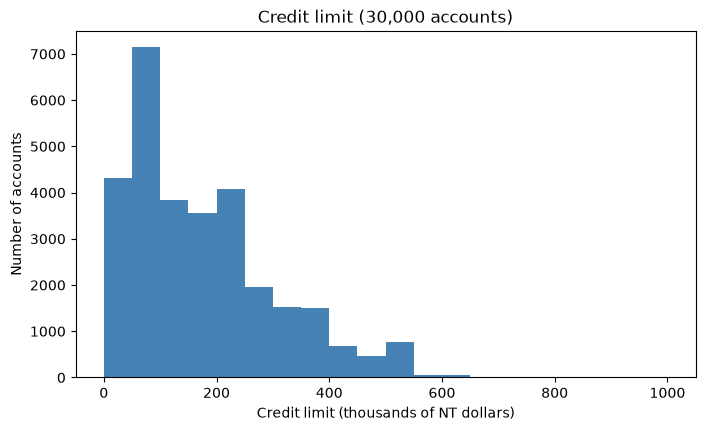

Accounts with a limit above 500,000: 206


In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# the limits in thousands of NT dollars, in bars 50 thousand wide
ax.hist(cards['LIMIT_BAL'] / 1000, bins=range(0, 1050, 50), color='steelblue')

ax.set_title('Credit limit (30,000 accounts)')
ax.set_xlabel('Credit limit (thousands of NT dollars)')
ax.set_ylabel('Number of accounts')

plt.show()

print('Accounts with a limit above 500,000:', (cards['LIMIT_BAL'] > 500_000).sum())

* The tallest bar is the second, limits from 50 to under 100 thousand NT dollars, which holds the 3,365 accounts at exactly 50 thousand. From there the bars fall away to the right. 206 accounts have a limit above 500,000 NT dollars, and they are the thin tail.

### 3.2 Age

Q. What are the summary statistics of age, and what does its histogram look like?

count    30000.0
mean        35.5
std          9.2
min         21.0
25%         28.0
50%         34.0
75%         41.0
max         79.0
Name: AGE, dtype: float64
Skew: 0.73
Different ages: 56


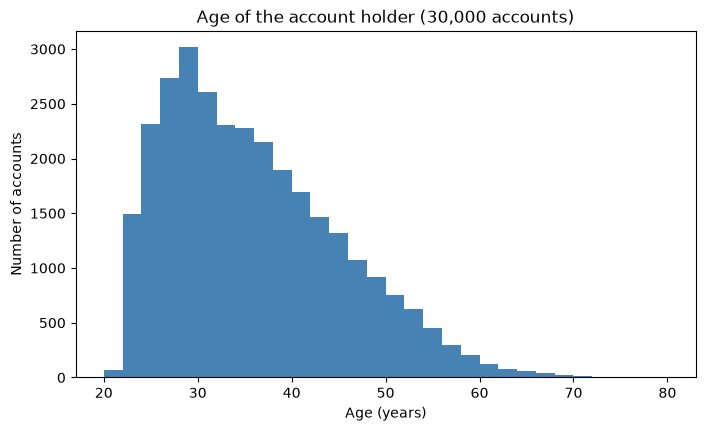

In [16]:
print(cards['AGE'].describe().round(1))
print('Skew:', round(cards['AGE'].skew(), 2))
print('Different ages:', cards['AGE'].nunique())

fig, ax = plt.subplots(figsize=(8, 4.5))

# one bar for each two years of age, from 20 to 80
ax.hist(cards['AGE'], bins=range(20, 82, 2), color='steelblue')

ax.set_title('Age of the account holder (30,000 accounts)')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of accounts')

plt.show()

* Ages run from 21 to 79. The median is 34 and the mean is 35.5.
* The middle half of the accounts is between 28 and 41. The skew is 0.73: a peak in the late twenties and a tail to the right.

### 3.3 Bill amounts

Q. What are the summary statistics of the September bill, `BILL_AMT1`?

In [17]:
print(cards['BILL_AMT1'].describe().round(0))
print('Skew:', round(cards['BILL_AMT1'].skew(), 2))

count     30000.0
mean      51223.0
std       73636.0
min     -165580.0
25%        3559.0
50%       22382.0
75%       67091.0
max      964511.0
Name: BILL_AMT1, dtype: float64
Skew: 2.66


* The median September bill is 22,382 NT dollars and the mean is 51,223, more than twice the median. The skew is 2.66, a longer right tail than the credit limit has.
* The minimum is -165,580 NT dollars. **A bill below zero.**

Q. How many September bills are below zero, how many are zero, and how many are above the account's credit limit?

In [18]:
print('Bills below zero:', (cards['BILL_AMT1'] < 0).sum())
print('Bills of exactly zero:', (cards['BILL_AMT1'] == 0).sum())
print('Bills above the credit limit:', (cards['BILL_AMT1'] > cards['LIMIT_BAL']).sum())

# the account with the lowest bill
lowest = cards.loc[cards['BILL_AMT1'].idxmin(), ['ID', 'LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1', 'default']]
print(lowest)

# the bills below zero in each of the six months
bill_columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
print((cards[bill_columns] < 0).sum())

Bills below zero: 590
Bills of exactly zero: 2008
Bills above the credit limit: 2115
ID            12331
LIMIT_BAL    300000
BILL_AMT1   -165580
PAY_AMT1     505000
default           0
Name: 12330, dtype: int64
BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688
dtype: int64


* 590 September bills are below zero, 2,008 are exactly zero, and 2,115 are above the account's credit limit.
* The lowest is account 12331: a bill of -165,580 NT dollars, on a limit of 300,000, with 505,000 paid in September.
* Every one of the six months has bills below zero, between 590 and 688 of them.
* **The documentation says only "Amount of bill statement (NT dollar)".** It does not say what a bill below zero means, or whether a bill can be above the limit. This notebook does not guess. The values are kept, counted, and reported as they are.
* They matter in section 6, where the bill is divided by the limit and a payment is divided by the bill.

Q. Draw the histogram of the September bill.

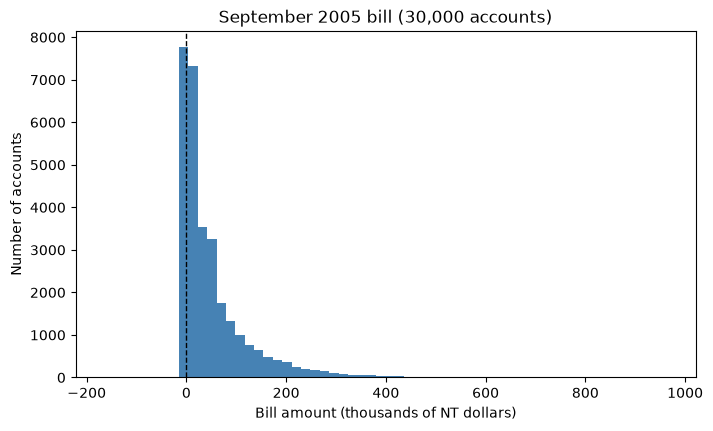

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# the bills in thousands of NT dollars, in 60 bars
ax.hist(cards['BILL_AMT1'] / 1000, bins=60, color='steelblue')

# a line at zero, to show the bills below it
ax.axvline(0, color='black', linewidth=1, linestyle='--')

ax.set_title('September 2005 bill (30,000 accounts)')
ax.set_xlabel('Bill amount (thousands of NT dollars)')
ax.set_ylabel('Number of accounts')

plt.show()

* Most of the accounts are in the few bars at and just right of the dashed zero line, and the tail runs out towards 964,511 NT dollars, the largest bill. The 590 bills below zero lie to the left of the line. Apart from the bar that crosses the line, their bars are too short to see at this scale.

### 3.4 Payment amounts

Q. What are the summary statistics of the amount paid in September, `PAY_AMT1`?

In [20]:
print(cards['PAY_AMT1'].describe().round(0))
print('Skew:', round(cards['PAY_AMT1'].skew(), 2))
print('Payments of zero:', (cards['PAY_AMT1'] == 0).sum())
print('Payments above 50,000:', (cards['PAY_AMT1'] > 50_000).sum())

count     30000.0
mean       5664.0
std       16563.0
min           0.0
25%        1000.0
50%        2100.0
75%        5006.0
max      873552.0
Name: PAY_AMT1, dtype: float64
Skew: 14.67
Payments of zero: 5249
Payments above 50,000: 471


* The median payment is 2,100 NT dollars and the mean is 5,664, well over twice the median. The largest is 873,552.
* The skew is 14.67, by far the most skewed column so far today. 5,249 accounts paid nothing in September, and 471 paid more than 50,000.
* With a column this skewed the mean describes almost no account. The median and the quartiles are the figures to quote.

Q. Draw the histogram of the September payments of 50,000 NT dollars or less.

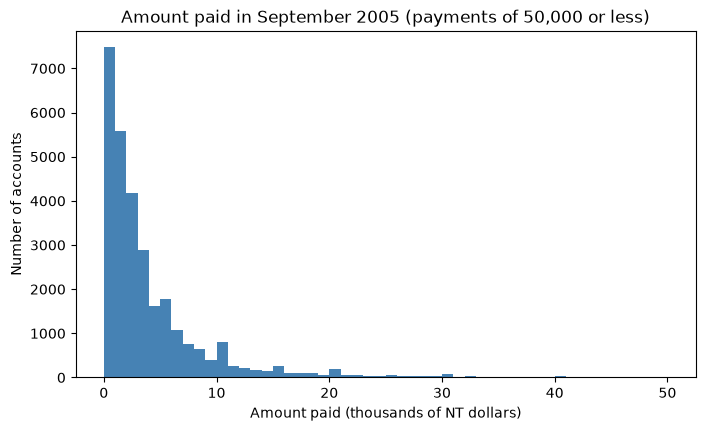

Accounts shown: 29529  accounts not shown: 471


In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# keep the payments of 50,000 or less, in thousands, in bars 1 thousand wide
shown = cards.loc[cards['PAY_AMT1'] <= 50_000, 'PAY_AMT1'] / 1000
ax.hist(shown, bins=range(0, 51, 1), color='steelblue')

ax.set_title('Amount paid in September 2005 (payments of 50,000 or less)')
ax.set_xlabel('Amount paid (thousands of NT dollars)')
ax.set_ylabel('Number of accounts')

plt.show()

print('Accounts shown:', len(shown), ' accounts not shown:', len(cards) - len(shown))

* 29,529 accounts are shown and the 471 with a payment above 50,000 NT dollars are not. The title says so. A chart that leaves rows out has to say which.
* Even inside this range the first bars hold most of the accounts.

**Excel side by side.**

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| Mean limit | `cards['LIMIT_BAL'].mean()` | `=AVERAGE(B2:B30001)` | 167,484 |
| Median limit | `cards['LIMIT_BAL'].median()` | `=MEDIAN(B2:B30001)` | 140,000 |
| Skew of the September payment | `cards['PAY_AMT1'].skew()` | `=SKEW(S2:S30001)` | 14.67 |
| Bills below zero | `(cards['BILL_AMT1'] < 0).sum()` | `=COUNTIF(M2:M30001, "<0")` | 590 |
| Bills above the limit | `(cards['BILL_AMT1'] > cards['LIMIT_BAL']).sum()` | `=SUMPRODUCT(--(M2:M30001 > B2:B30001))` | 2,115 |
| Payments of zero | `(cards['PAY_AMT1'] == 0).sum()` | `=COUNTIF(S2:S30001, 0)` | 5,249 |

The histogram is Insert, Insert Statistic Chart, Histogram on the column.

**Observations: one column at a time**

* The median credit limit is 140,000 NT dollars and the mean 167,484. The limits are round numbers: 81 different values, the most common 50,000 on 3,365 accounts.
* Ages run from 21 to 79, with a median of 34.
* The median September bill is 22,382 NT dollars and the mean 51,223. 590 bills are below zero and 2,115 are above the credit limit. The documentation does not explain either.
* The median September payment is 2,100 NT dollars and the mean 5,664, with a skew of 14.67. 5,249 accounts paid nothing.

## 4.0 The outcome against one column

Section 2 found the default rate of the whole file. This section finds it for groups of accounts. The tool is `groupby`, and the rate of each group is the mean of `default` in that group.

Four of the columns describe people: sex, education, marital status, and age. They are in the file and they are described like any other column, with the rate and the count. **Differences between groups in this file do not explain themselves, and they are not a basis for treating people differently.**

### 4.1 Counts are not rates

**Predict 2**

Of the 6,636 accounts that defaulted, 2,873 have the label `male` and 3,763 have the label `female`. In which of the two groups was the default rate higher?

> A) `female`, because it has more defaults
>
> B) `male`
>
> C) these two numbers cannot say

Decide, then run the cell.

In [22]:
# for each group: count is the number of accounts, sum is the number of defaults, mean is the rate
by_sex = cards.groupby('sex')['default'].agg(['count', 'sum', 'mean'])
by_sex.columns = ['accounts', 'defaults', 'rate_pct']

# the rate in percent, to two decimal places
by_sex['rate_pct'] = (by_sex['rate_pct'] * 100).round(2)

print(by_sex)

        accounts  defaults  rate_pct
sex                                 
female     18112      3763     20.78
male       11888      2873     24.17


* The answer is C. A count of defaults says nothing about a rate until it is divided by the number of accounts in the group, and the question gave only the defaults.
* With the accounts beside them: 3,763 defaults among 18,112 accounts labelled `female` is 20.78 percent, and 2,873 among 11,888 labelled `male` is 24.17 percent. The group with more defaults had the lower rate, because it has many more accounts.
* The table has the three columns every rate table needs: accounts, defaults, and rate. The same three lines of code will be used for every grouping today, so they go into a function, as in notebook 05.

Q. Write a function that returns the accounts, defaults, and default rate for the groups of any column.

In [23]:
def rate_table(column):
    # group the accounts by the column, then count, add up, and average the outcome
    table = cards.groupby(column)['default'].agg(['count', 'sum', 'mean'])
    table.columns = ['accounts', 'defaults', 'rate_pct']
    # the rate in percent, to two decimal places
    table['rate_pct'] = (table['rate_pct'] * 100).round(2)
    return table


# the same table as above, from the function
print(rate_table('sex'))

        accounts  defaults  rate_pct
sex                                 
female     18112      3763     20.78
male       11888      2873     24.17


* The function gives the same table. It reads `cards` each time it is called, so a column added to `cards` later can be used straight away.

**Excel side by side.** The three columns of the table are `COUNTIF`, `SUMIF`, and `AVERAGEIF` on the same condition.

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| Accounts in a group | `count` | `=COUNTIF(C2:C30001, 1)` | 11,888 |
| Defaults in a group | `sum` | `=SUMIF(C2:C30001, 1, Y2:Y30001)` | 2,873 |
| Default rate of a group | `mean` | `=AVERAGEIF(C2:C30001, 1, Y2:Y30001)` | 0.2417 |

`AVERAGEIF` averages the cells of column Y on the rows where column C holds 1. It is the same number as the `SUMIF` divided by the `COUNTIF`.

### 4.2 Education

Q. What was the default rate for each education label, and for each education code?

In [24]:
# by label, in the order of the documentation, with the undocumented codes last
education_order = ['graduate school', 'university', 'high school', 'others', 'not documented']
by_education = rate_table('education').loc[education_order]
print(by_education)

# by code, to see the three undocumented codes one at a time
print(rate_table('EDUCATION'))

                 accounts  defaults  rate_pct
education                                    
graduate school     10585      2036     19.23
university          14030      3330     23.73
high school          4917      1237     25.16
others                123         7      5.69
not documented        345        26      7.54
           accounts  defaults  rate_pct
EDUCATION                              
0                14         0      0.00
1             10585      2036     19.23
2             14030      3330     23.73
3              4917      1237     25.16
4               123         7      5.69
5               280        18      6.43
6                51         8     15.69


* The three large groups: 19.23 percent of the 10,585 accounts labelled graduate school defaulted, 23.73 percent of the 14,030 labelled university, and 25.16 percent of the 4,917 labelled high school.
* The two small groups have much lower rates: 5.69 percent for `others`, which is 7 defaults in 123 accounts, and 7.54 percent for `not documented`, 26 defaults in 345 accounts.
* By code, the undocumented group is three different rows: code 0 with 0 defaults in 14 accounts, code 5 with 18 in 280 (6.43 percent), and code 6 with 8 in 51 (15.69 percent). The label `not documented` is a bucket of three codes that may have nothing to do with each other.
* The accounts column adds up to 30,000. No account was lost, because the undocumented codes were kept.

Q. Draw the default rate by education label, with the rate of the whole file as a reference line.

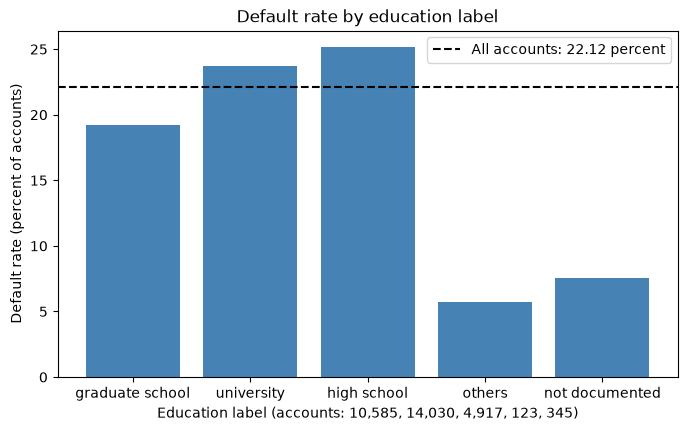

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# one bar for each label: its default rate in percent
ax.bar(by_education.index, by_education['rate_pct'], color='steelblue')

# axhline() draws the rate of all 30,000 accounts across the chart
ax.axhline(overall_rate_pct, color='black', linestyle='--', label='All accounts: 22.12 percent')

ax.legend()
ax.set_title('Default rate by education label')
ax.set_xlabel('Education label (accounts: 10,585, 14,030, 4,917, 123, 345)')
ax.set_ylabel('Default rate (percent of accounts)')

plt.show()

* Two bars reach above the dashed line and three stay below it. The reference line turns each bar into a comparison with the whole file.
* All five bars are the same width, and a bar on 123 accounts looks as solid as one on 14,030. The chart cannot show how many accounts are behind a bar, so the counts are written into the axis label and the table is printed above.

### 4.3 Marital status

Q. What was the default rate for each marital status label?

In [26]:
marriage_order = ['married', 'single', 'others', 'not documented']
print(rate_table('marriage').loc[marriage_order])

                accounts  defaults  rate_pct
marriage                                    
married            13659      3206     23.47
single             15964      3341     20.93
others               323        84     26.01
not documented        54         5      9.26


* 23.47 percent of the 13,659 accounts labelled married defaulted, and 20.93 percent of the 15,964 labelled single.
* The two small groups: 26.01 percent for `others`, 84 defaults in 323 accounts, and 9.26 percent for `not documented`, 5 defaults in 54 accounts.

### 4.4 Age bands

Age holds 56 different values, too many for a table of groups. `pd.cut()`, from notebook 08, sorts a number column into bands with edges that you choose.

Q. Sort the ages into five bands and find the default rate of each.

In [27]:
# the edges of the bands. Each band takes the ages above its left edge, up to and including its right edge.
age_edges = [20, 30, 40, 50, 60, 80]
age_names = ['21 to 30', '31 to 40', '41 to 50', '51 to 60', '61 to 79']

# pd.cut() gives each account the name of the band its age falls in
cards['age_band'] = pd.cut(cards['AGE'], bins=age_edges, labels=age_names)

by_age = rate_table('age_band')
print(by_age)

          accounts  defaults  rate_pct
age_band                              
21 to 30     11013      2471     22.44
31 to 40     10713      2189     20.43
41 to 50      6005      1399     23.30
51 to 60      1997       504     25.24
61 to 79       272        73     26.84


* The lowest rate is in the band 31 to 40: 20.43 percent of 10,713 accounts. The band 21 to 30 is at 22.44 percent of 11,013 accounts.
* From 31 to 40 upward the rate is higher in each band: 23.30 percent, then 25.24, then 26.84 percent in the band 61 to 79.
* The last band has 272 accounts, against more than 10,000 in each of the first two. Its rate rests on 73 defaults.
* The rates do not move in one direction across the bands: down from the first band to the second, then up. Section 7 comes back to that.

**Excel side by side.** A band for each row can be built in two ways.

| Way | Formula in a helper column, for row 2 |
| --- | --- |
| `IFS`, in Excel 2019 and later and in Microsoft 365, which tests the conditions in order and returns the value of the first one that is true | `=IFS(F2 <= 30, "21 to 30", F2 <= 40, "31 to 40", F2 <= 50, "41 to 50", F2 <= 60, "51 to 60", TRUE, "61 to 79")` |
| `VLOOKUP` with approximate match | `=VLOOKUP(F2, $AE$2:$AF$6, 2, TRUE)` |

For the `VLOOKUP`, type the lowest age of each band, 21, 31, 41, 51, and 61, into AE2 to AE6 and the band names into AF2 to AF6. With `TRUE` as the last argument, `VLOOKUP` finds the largest value in the first column that is less than or equal to the age, which is the band the age belongs to. The first column must be sorted from smallest to largest. With the band in helper column Z, the rate of a band is `=AVERAGEIF(Z2:Z30001, "31 to 40", Y2:Y30001)`, which returns 0.2043, and its count is `=COUNTIF(Z2:Z30001, "31 to 40")`, which returns 10,713.

### 4.5 Credit limit bands

For age the edges were chosen by hand. Another way is to let the data choose them, so that each band holds about the same number of accounts. `pd.qcut()` does that: the `q` is for quantile. `pd.qcut(column, 4)` cuts at the quartiles.

**Predict 3**

```
limit_band = pd.qcut(cards['LIMIT_BAL'], 4)
print(limit_band.value_counts().sort_index())
```

The file has 30,000 accounts. How many are in each of the four bands?

> A) exactly 7,500 in each
>
> B) not exactly 7,500 in each
>
> C) an error, because 30,000 limits cannot be cut into four

Decide, then run the cell.

In [28]:
# qcut() finds the edges that split the accounts into 4 groups of about equal size
limit_band = pd.qcut(cards['LIMIT_BAL'], 4)
print(limit_band.value_counts().sort_index())

# the edges it used are the quartiles
print(cards['LIMIT_BAL'].quantile([0.25, 0.5, 0.75]))

LIMIT_BAL
(9999.999, 50000.0]      7676
(50000.0, 140000.0]      7614
(140000.0, 240000.0]     7643
(240000.0, 1000000.0]    7067
Name: count, dtype: int64
0.25     50000.0
0.50    140000.0
0.75    240000.0
Name: LIMIT_BAL, dtype: float64


* The answer is B. The four bands hold 7,676, 7,614, 7,643, and 7,067 accounts.
* The edges are the quartiles: 50,000, 140,000, and 240,000 NT dollars. Each band is written as an interval. `(50000.0, 140000.0]` means above 50,000 and up to and including 140,000. The first band starts a hair below the minimum of 10,000 so that the minimum is inside it.
* The bands are uneven because of ties. Section 3.1 found 3,365 accounts with a limit of exactly 50,000. Accounts with the same limit cannot be split between two bands, so all of them go into the first, and it ends up with 7,676.
* `qcut` chooses edges so that the bands are as even as the data allows. `cut` uses the edges you give it and lets the counts fall where they may.

Q. Give the four bands readable names, and find the default rate of each.

                      accounts  defaults  rate_pct
limit_band                                        
10,000 to 50,000          7676      2440     31.79
50,001 to 140,000         7614      1882     24.72
140,001 to 240,000        7643      1326     17.35
240,001 to 1,000,000      7067       988     13.98


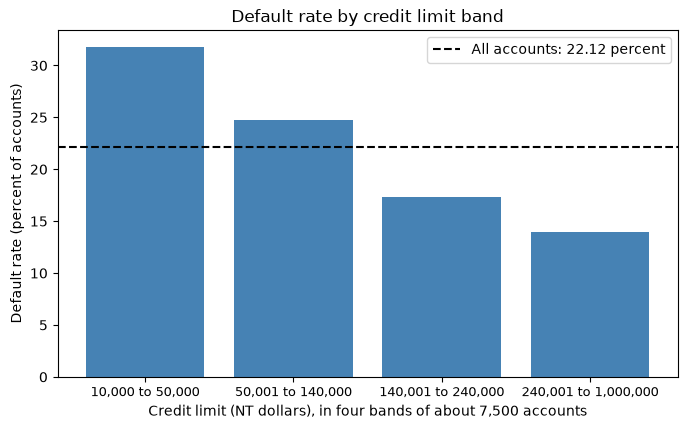

In [29]:
# the same four bands, with names in place of the intervals
limit_names = ['10,000 to 50,000', '50,001 to 140,000', '140,001 to 240,000', '240,001 to 1,000,000']
cards['limit_band'] = pd.qcut(cards['LIMIT_BAL'], 4, labels=limit_names)

by_limit = rate_table('limit_band')
print(by_limit)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(by_limit.index, by_limit['rate_pct'], color='steelblue')
ax.axhline(overall_rate_pct, color='black', linestyle='--', label='All accounts: 22.12 percent')

ax.legend()
ax.set_title('Default rate by credit limit band')
ax.set_xlabel('Credit limit (NT dollars), in four bands of about 7,500 accounts')
ax.set_ylabel('Default rate (percent of accounts)')

# slightly smaller band names, so that they do not run into each other
ax.tick_params(axis='x', labelsize=9)

plt.show()

* The default rate is lower in each band of larger limits: 31.79 percent of the 7,676 accounts with a limit of 50,000 NT dollars or less, then 24.72 percent, then 17.35 percent, and 13.98 percent of the 7,067 accounts with a limit above 240,000.
* Each band has more than 7,000 accounts, so none of the four rates rests on a thin group.
* This is an association in the file, and the file cannot say what lies behind it. The documentation does not say how the lender set the limits.

Q. Compare the credit limits of the accounts that defaulted with those that did not, with a box plot.

No default - accounts: 23364  median limit: 150.0  lowest: 10.0  highest: 1000.0 thousand NT dollars
Default    - accounts: 6636  median limit: 90.0  lowest: 10.0  highest: 740.0 thousand NT dollars


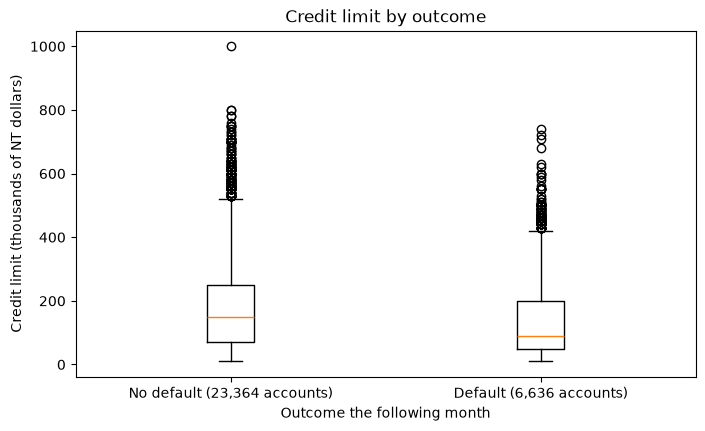

In [30]:
# the limits of each outcome group, in thousands of NT dollars
limit_no_default = cards.loc[cards['default'] == 0, 'LIMIT_BAL'] / 1000
limit_default = cards.loc[cards['default'] == 1, 'LIMIT_BAL'] / 1000

print('No default - accounts:', len(limit_no_default), ' median limit:', limit_no_default.median(),
      ' lowest:', limit_no_default.min(), ' highest:', limit_no_default.max(), 'thousand NT dollars')
print('Default    - accounts:', len(limit_default), ' median limit:', limit_default.median(),
      ' lowest:', limit_default.min(), ' highest:', limit_default.max(), 'thousand NT dollars')

fig, ax = plt.subplots(figsize=(8, 4.5))

# ax.boxplot() draws one box for each group in the list. tick_labels= names the boxes.
ax.boxplot([limit_no_default, limit_default], tick_labels=['No default (23,364 accounts)', 'Default (6,636 accounts)'])

ax.set_title('Credit limit by outcome')
ax.set_xlabel('Outcome the following month')
ax.set_ylabel('Credit limit (thousands of NT dollars)')

plt.show()

* The median limit of the 23,364 accounts that did not default is 150.0 thousand NT dollars. The median of the 6,636 that defaulted is 90.0 thousand.
* The two boxes overlap over most of their height. Both groups hold accounts at 10 thousand and accounts above 500 thousand. A lower median is a statement about the middle of a group, not about each account in it.
* This is the same association as the bar chart, seen from the other side: there the accounts were grouped by limit and the outcome was averaged, and here they are grouped by outcome and the limit is summarized.

`qcut` can fail where `cut` cannot. The September payment has many accounts at one value.

Q. Cut the September payment, `PAY_AMT1`, into ten bands of equal size.

In [31]:
# ten bands of about 3,000 accounts each
pd.qcut(cards['PAY_AMT1'], 10)

ValueError: Bin edges must be unique: Index([               0.0,                0.0,              316.0,
       1263.7000000000025,             1724.0,             2100.0,
                   3000.0,  4309.300000000007,  6192.200000000001,
                  10300.0,           873552.0],
      dtype='float64', name='PAY_AMT1').
You can drop duplicate edges by setting the 'duplicates' kwarg

* A `ValueError`. The traceback is long because the error was raised inside pandas, and the lines to read are the last ones: `Bin edges must be unique`, followed by the edges pandas worked out. The first two are both 0.0.
* Section 3.4 found 5,249 accounts with a payment of zero. That is more than a tenth of the 30,000. So the lowest payment is 0 and the payment one tenth of the way up is also 0, and a band from 0 to 0 is not a band.
* The error message offers a way out, `duplicates='drop'`, which merges the two edges and returns nine bands where ten were asked for. That runs, and it quietly changes what was asked. The plainer fix is to see why the edges collide and choose bands that fit the data.

Q. Put the accounts that paid nothing in a band of their own, and cut the rest with edges chosen by hand.

In [32]:
# the first band holds only 0. The others take payments above the left edge, up to and including the right edge.
payment_edges = [-1, 0, 2000, 5000, 20000, 900000]
payment_names = ['nothing', '1 to 2,000', '2,001 to 5,000', '5,001 to 20,000', 'above 20,000']

cards['payment_band'] = pd.cut(cards['PAY_AMT1'], bins=payment_edges, labels=payment_names)

print(rate_table('payment_band'))

                 accounts  defaults  rate_pct
payment_band                                 
nothing              5249      1887     35.95
1 to 2,000           9166      2085     22.75
2,001 to 5,000       8021      1624     20.25
5,001 to 20,000      6245       915     14.65
above 20,000         1319       125      9.48


* The 5,249 accounts that paid nothing in September are a band of their own, and 35.95 percent of them defaulted. The rate is lower in each band of larger payments: 22.75 percent of 9,166 accounts, 20.25 percent of 8,021, 14.65 percent of 6,245, and 9.48 percent of the 1,319 accounts that paid more than 20,000 NT dollars.
* `pd.cut()` with edges chosen by hand has no trouble with ties, because the edges do not depend on the data.

**Excel side by side.** The edges that `qcut` finds are percentiles, and Excel has a function for them.

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| First quartile of the limit | `cards['LIMIT_BAL'].quantile(0.25)` | `=PERCENTILE.INC(B2:B30001, 0.25)` | 50,000 |
| Median | `cards['LIMIT_BAL'].quantile(0.5)` | `=PERCENTILE.INC(B2:B30001, 0.5)` | 140,000 |
| Third quartile | `cards['LIMIT_BAL'].quantile(0.75)` | `=PERCENTILE.INC(B2:B30001, 0.75)` | 240,000 |
| Tenth percentile of the September payment | `cards['PAY_AMT1'].quantile(0.1)` | `=PERCENTILE.INC(S2:S30001, 0.1)` | 0 |
| The band of each account | `pd.qcut(cards['LIMIT_BAL'], 4, labels=limit_names)` | `=VLOOKUP(B2, $AH$2:$AI$5, 2, TRUE)` | text |
| Accounts in a band | `by_limit['accounts']` | `=COUNTIFS(B2:B30001, ">50000", B2:B30001, "<=140000")` | 7,614 |
| Default rate of a band | `by_limit['rate_pct']` | `=AVERAGEIFS(Y2:Y30001, B2:B30001, ">50000", B2:B30001, "<=140000")` | 0.2472 |

For the `VLOOKUP`, type the lowest limit of each band, 10000, 50001, 140001, and 240001, into AH2 to AH5 and the band names into AI2 to AI5. The fourth row of the table shows where the error came from: the tenth percentile of the payments is 0, the same as the minimum.

### 4.6 Repayment status in September

Q. What was the default rate for each value of `PAY_0`, the repayment status in September 2005?

In [33]:
by_status = rate_table('PAY_0')
print(by_status)

print('Accounts with a status of 4 or more:', by_status.loc[4:, 'accounts'].sum())

       accounts  defaults  rate_pct
PAY_0                              
-2         2759       365     13.23
-1         5686       954     16.78
 0        14737      1888     12.81
 1         3688      1252     33.95
 2         2667      1844     69.14
 3          322       244     75.78
 4           76        52     68.42
 5           26        13     50.00
 6           11         6     54.55
 7            9         7     77.78
 8           19        11     57.89
Accounts with a status of 4 or more: 141


* Among the documented codes: 16.78 percent of the 5,686 accounts with -1, "pay duly", defaulted the following month. With 1, a payment delay of one month, it was 33.95 percent of 3,688 accounts. With 2, a delay of two months, it was 69.14 percent of 2,667 accounts.
* The two undocumented codes: 13.23 percent of the 2,759 accounts with code -2, and 12.81 percent of the 14,737 accounts with code 0. Those are the two lowest rates in the table, and code 0 is the largest group. What the two codes mean is not in the documentation, and the rates do not tell us.
* The codes 4 to 8 have 141 accounts between them. Their rates run from 50.00 to 77.78 percent and jump about from one code to the next: 11 accounts with code 6, 9 with code 7. Those are thin groups, and their rates should be read with their counts.

Q. Draw the default rate for each September status, with the reference line.

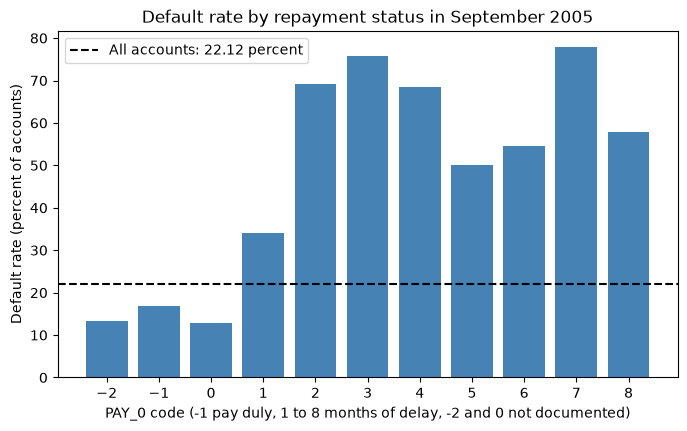

In [34]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(by_status.index, by_status['rate_pct'], color='steelblue')
ax.axhline(overall_rate_pct, color='black', linestyle='--', label='All accounts: 22.12 percent')

# one tick for each code
ax.set_xticks(by_status.index)

ax.legend(loc='upper left')
ax.set_title('Default rate by repayment status in September 2005')
ax.set_xlabel('PAY_0 code (-1 pay duly, 1 to 8 months of delay, -2 and 0 not documented)')
ax.set_ylabel('Default rate (percent of accounts)')

plt.show()

* The three bars on the left, codes -2, -1, and 0, are below the dashed line. Every bar from code 1 upward is above it.
* The bars for codes 4 to 8 are as wide as the bar for code 0, and they stand for 141 accounts against 14,737. The table above is part of the chart.

**Observations: the outcome against one column**

* Sex: 24.17 percent of the 11,888 accounts labelled male defaulted and 20.78 percent of the 18,112 labelled female.
* Education: 19.23 percent (graduate school, 10,585 accounts), 23.73 percent (university, 14,030), 25.16 percent (high school, 4,917), 5.69 percent (others, 123), and 7.54 percent (not documented, 345).
* Marital status: 23.47 percent (married, 13,659 accounts), 20.93 percent (single, 15,964), 26.01 percent (others, 323), and 9.26 percent (not documented, 54).
* Age: lowest in the band 31 to 40, at 20.43 percent of 10,713 accounts, and highest in the band 61 to 79, at 26.84 percent of 272 accounts.
* Credit limit: from 31.79 percent in the band up to 50,000 NT dollars (7,676 accounts) to 13.98 percent in the band above 240,000 (7,067 accounts).
* September repayment status: 12.81 percent with the undocumented code 0 (14,737 accounts), 16.78 percent with -1, pay duly (5,686), 33.95 percent with a delay of one month (3,688), and 69.14 percent with a delay of two months (2,667).
* Each of these is the rate in a group of this file, with its count. None of them says why.

## 5.0 The outcome against two columns

The last section used one grouping at a time. A pivot table uses two: one down the side and one across the top, with the default rate of each combination in the cell. The two groupings here are the September repayment status and the credit limit band.

The status codes 3 to 8 are thin, so they are put in one band first. `pd.cut()` does it, with one band for each of the other codes.

Q. Put the September status into six groups, keeping each of -2, -1, 0, 1, and 2 on its own.

In [35]:
# each band takes the codes above its left edge, up to and including its right edge.
# So the first band holds only -2, the second only -1, and the last holds 3 to 8.
status_edges = [-3, -2, -1, 0, 1, 2, 8]
status_names = ['-2', '-1', '0', '1', '2', '3 to 8']

cards['status_group'] = pd.cut(cards['PAY_0'], bins=status_edges, labels=status_names)

print(cards['status_group'].value_counts().sort_index())

status_group
-2         2759
-1         5686
0         14737
1          3688
2          2667
3 to 8      463
Name: count, dtype: int64


* The first five groups have the counts of section 1.3: 2,759, 5,686, 14,737, 3,688, and 2,667. The group `3 to 8` holds the other 463 accounts.
* No code was renamed or merged with a code of a different meaning. The six thin delay codes were put together, and the group's name says which.

Q. Build the pivot table of default rates, in percent: status group down the side, credit limit band across the top.

In [36]:
# the mean of default in each cell is the default rate of that combination
rate_pivot = pd.pivot_table(cards, values='default', index='status_group', columns='limit_band', aggfunc='mean')

# in percent, to one decimal place
rate_pivot = (rate_pivot * 100).round(1)
print(rate_pivot)

# the same table with the count of accounts in each cell
count_pivot = pd.pivot_table(cards, values='default', index='status_group', columns='limit_band', aggfunc='count')
print(count_pivot)

print('Accounts in the count table:', count_pivot.sum().sum())

limit_band    10,000 to 50,000  50,001 to 140,000  140,001 to 240,000  \
status_group                                                            
-2                        10.9               11.8                12.3   
-1                        25.7               21.4                16.2   
0                         19.2               13.2                 9.0   
1                         42.2               35.3                27.8   
2                         68.4               71.1                67.7   
3 to 8                    71.5               67.6                75.9   

limit_band    240,001 to 1,000,000  
status_group                        
-2                            14.7  
-1                            10.7  
0                              7.4  
1                             26.1  
2                             67.5  
3 to 8                        83.9  
limit_band    10,000 to 50,000  50,001 to 140,000  140,001 to 240,000  \
status_group                                  

* Each cell of the first table is a default rate. Top left: 10.9 percent of the accounts with status code -2 and a limit of 50,000 NT dollars or less. The second table says that cell is 174 accounts.
* The 24 counts add up to 30,000. Every account is in exactly one cell.
* The counts are far from even. The largest cell is 4,288 accounts, status code 0 with a limit of 50,001 to 140,000. The smallest is 31 accounts, status 3 to 8 with a limit above 240,000.

Q. Draw the two tables as heatmaps.

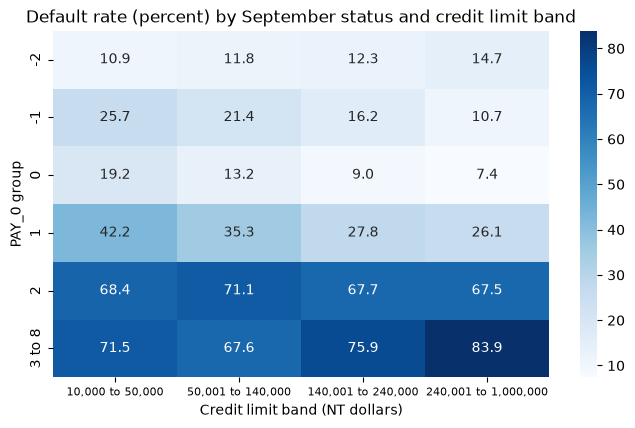

In [37]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# annot=True writes the number in each cell, and fmt='.1f' gives it one decimal place
sns.heatmap(rate_pivot, annot=True, fmt='.1f', cmap='Blues', ax=ax)

ax.set_title('Default rate (percent) by September status and credit limit band')
ax.set_xlabel('Credit limit band (NT dollars)')
ax.set_ylabel('PAY_0 group')

# keep the band names level and readable
ax.tick_params(axis='x', rotation=0, labelsize=8)

plt.show()

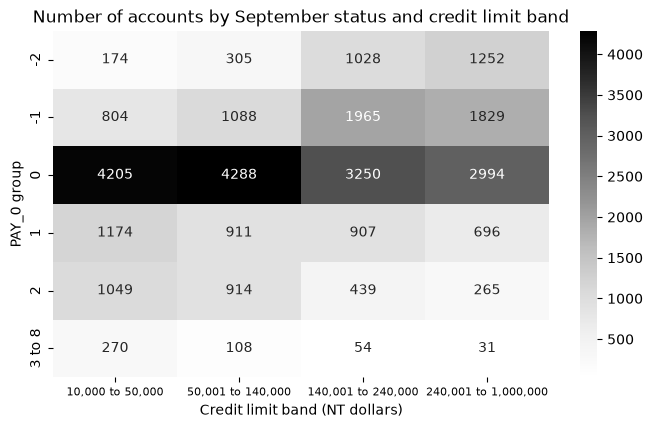

In [38]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# fmt='d' writes whole numbers
sns.heatmap(count_pivot, annot=True, fmt='d', cmap='Greys', ax=ax)

ax.set_title('Number of accounts by September status and credit limit band')
ax.set_xlabel('Credit limit band (NT dollars)')
ax.set_ylabel('PAY_0 group')
ax.tick_params(axis='x', rotation=0, labelsize=8)

plt.show()

* In the first heatmap the dark cells are the two bottom rows: with a status of 2, or of 3 to 8, between 67.5 and 83.9 percent of the accounts defaulted, in every limit band.
* The darkest cell is 83.9 percent, bottom right. The second heatmap shows that it is the palest cell there: 31 accounts. The highest rate in the table rests on the fewest accounts.
* In the rows for codes -1, 0, and 1, the rate is lower in each band of larger limits: for code 0 it goes from 19.2 percent to 7.4 percent. In the row for code 2 it does not: 68.4, 71.1, 67.7, and 67.5 percent. In the row for code -2 it runs the other way, from 10.9 to 14.7 percent.
* So the association between limit and default rate of section 4.5 is not the same in every status group. One grouping at a time could not show that.
* **Read the two heatmaps together.** The first says what the rate was. The second says how much to lean on it.

**Excel side by side.** A cell of each table is one formula with two conditions. With the September status in column G and the limit in column B:

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| Accounts with status 2 and a limit up to 50,000 | `count_pivot` | `=COUNTIFS(G2:G30001, 2, B2:B30001, "<=50000")` | 1,049 |
| Their default rate | `rate_pivot` | `=AVERAGEIFS(Y2:Y30001, G2:G30001, 2, B2:B30001, "<=50000")` | 0.684 |
| The whole table of rates | `pd.pivot_table(cards, values='default', index='status_group', columns='limit_band', aggfunc='mean')` | a pivot table: the status group in Rows, the limit band in Columns, and the outcome in Values, summarized by Average | 6 rows, 4 columns |
| The whole table of counts | the same with `aggfunc='count'` | the same pivot table with the outcome summarized by Count | 6 rows, 4 columns |
| The colours | `sns.heatmap(rate_pivot, annot=True)` | select the cells, then Home, Conditional Formatting, Color Scales | |

The pivot table needs the two bands as helper columns on the sheet, built with the `VLOOKUP` of section 4. To change how the outcome is summarized, open Value Field Settings and choose Average or Count. `AVERAGEIFS` returns `#DIV/0!` when no row meets both conditions, which is the empty cell of a pivot table.

**Observations: the outcome against two columns**

* With a September status of 2 or more, between 67.5 and 83.9 percent of the accounts defaulted in every credit limit band. With code 0 the rate ran from 19.2 percent in the lowest limit band to 7.4 percent in the highest.
* The highest rate in the table, 83.9 percent, is on the smallest cell, 31 accounts.
* The 24 cells hold from 31 to 4,288 accounts and add up to 30,000.

## 6.0 Derived columns

A derived column is one worked out from the columns of the file. Three are built here, each from a question a credit analyst would ask of a card account: how much of the limit is in use, how much of the bill was paid, and how often was a payment late.

### 6.1 Utilisation

**Utilisation** here is the September bill divided by the credit limit. A value of 0.5 means the bill was half of the limit.

Q. Add the utilisation of each account, and summarize it.

In [39]:
# the September bill as a share of the credit limit. Both are in NT dollars, so the ratio has no unit.
cards['utilisation'] = cards['BILL_AMT1'] / cards['LIMIT_BAL']

print(cards['utilisation'].describe().round(3))
print('Below zero:', (cards['utilisation'] < 0).sum(), ' exactly zero:', (cards['utilisation'] == 0).sum(),
      ' above 1:', (cards['utilisation'] > 1).sum())

count    30000.000
mean         0.424
std          0.411
min         -0.620
25%          0.022
50%          0.314
75%          0.830
max          6.455
Name: utilisation, dtype: float64
Below zero: 590  exactly zero: 2008  above 1: 2115


* The median utilisation is 0.314 and the mean is 0.424. A quarter of the accounts are at 0.022 or below and a quarter are at 0.830 or above.
* The limit is never zero, the smallest being 10,000 NT dollars, so the division is safe on every row.
* The oddities of the bill column carry over. 590 accounts have a utilisation below zero and 2,008 of exactly zero, the bills of section 3.3. 2,115 are above 1, the bills above the limit, and the largest is 6.455.
* None of those rows is changed or dropped. They get bands of their own below.

Q. Draw the histogram of utilisation.

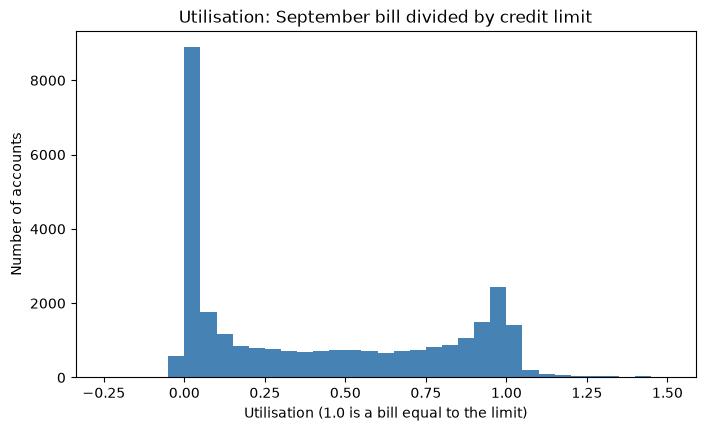

Accounts outside the range drawn: 166


In [40]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# range= sets the lowest and highest value drawn. Accounts outside it are left off the chart.
ax.hist(cards['utilisation'], bins=35, range=(-0.25, 1.5), color='steelblue')

ax.set_title('Utilisation: September bill divided by credit limit')
ax.set_xlabel('Utilisation (1.0 is a bill equal to the limit)')
ax.set_ylabel('Number of accounts')

plt.show()

outside = ((cards['utilisation'] < -0.25) | (cards['utilisation'] > 1.5)).sum()
print('Accounts outside the range drawn:', outside)

* Two crowds: a tall one at and just above zero, and a lower, wider one just below 1.0. Many accounts use almost none of the limit and many use almost all of it.
* 166 accounts are outside the range drawn, below -0.25 or above 1.5, and are left off the chart. The printed line says so.

Q. What was the default rate in bands of utilisation?

In [41]:
# np.inf is infinity: the first band has no lower end and the last has no upper end
utilisation_edges = [-np.inf, 0, 0.25, 0.5, 0.75, 1, np.inf]
utilisation_names = ['zero or below', 'above 0 to 0.25', 'above 0.25 to 0.5', 'above 0.5 to 0.75', 'above 0.75 to 1', 'above 1']

cards['utilisation_band'] = pd.cut(cards['utilisation'], bins=utilisation_edges, labels=utilisation_names)

print(rate_table('utilisation_band'))

                   accounts  defaults  rate_pct
utilisation_band                               
zero or below          2598       643     24.75
above 0 to 0.25       11440      1923     16.81
above 0.25 to 0.5      3588       780     21.74
above 0.5 to 0.75      3579       929     25.96
above 0.75 to 1        6680      1725     25.82
above 1                2115       636     30.07


* The lowest rate is in the band above 0 to 0.25: 16.81 percent of 11,440 accounts. The rate is higher in the bands above it: 21.74 percent, 25.96, 25.82, and 30.07 percent of the 2,115 accounts with a bill above the limit.
* The band `zero or below` does not continue that order. 24.75 percent of its 2,598 accounts defaulted, more than in the band next to it. Those are the accounts with a September bill of zero or less.
* Had the bills of zero or less been dropped as "bad data", 2,598 accounts and 643 defaults would have left the table unseen.

### 6.2 Share of the bill paid

The second derived column is the amount paid in September divided by the September bill. The documentation does not say whether the September payment was made against the September bill or an earlier one, so this is a ratio of two September figures and no more than that.

**Predict 4**

```
share_paid = cards['PAY_AMT1'] / cards['BILL_AMT1']
print(share_paid.mean())
```

2,008 accounts have a September bill of exactly zero. Notebook 03 showed that `5 / 0` in plain Python stops with a `ZeroDivisionError`. What does this print?

> A) nothing: it stops with a `ZeroDivisionError`
>
> B) a number between 0 and 1
>
> C) `inf`

Decide, then run the cell.

In [42]:
# the September payment divided by the September bill, on every row
share_paid = cards['PAY_AMT1'] / cards['BILL_AMT1']
print('Mean:', share_paid.mean())

# np.isinf() marks the cells that hold infinity, and isna() the cells that hold a missing value
print('Infinite:', np.isinf(share_paid).sum())
print('Missing:', share_paid.isna().sum())
print('Below zero:', (share_paid < 0).sum())

Mean: inf
Infinite: 540
Missing: 1468
Below zero: 304


* The answer is C: `inf`, infinity. pandas does not stop on a division by zero. Where a payment above zero is divided by a bill of zero it writes `inf`, on 540 rows. Where zero is divided by zero it writes a missing value, on 1,468 rows. 540 plus 1,468 is the 2,008 bills of zero.
* One `inf` is enough to make the mean `inf`. And 304 more rows have a share below zero, where a payment was divided by a bill below zero.
* No error and no warning. A ratio is only as sound as its denominator, and this denominator is zero or negative on 2,598 rows.

Q. Work out the share paid only where the bill is above zero, and summarize it.

In [43]:
# the accounts with a September bill above zero
has_bill = cards['BILL_AMT1'] > 0
print('Accounts with a bill above zero:', has_bill.sum(), ' others:', (~has_bill).sum())

# the share is worked out on those rows only. The other rows are left as missing values.
cards['share_paid'] = cards.loc[has_bill, 'PAY_AMT1'] / cards.loc[has_bill, 'BILL_AMT1']

print(cards['share_paid'].describe().round(3))
print('Missing:', cards['share_paid'].isna().sum())

Accounts with a bill above zero: 27402  others: 2598
count    27402.000
mean         1.776
std         76.574
min          0.000
25%          0.037
50%          0.061
75%          0.274
max      11453.667
Name: share_paid, dtype: float64
Missing: 2598


* 27,402 accounts have a bill above zero and get a share. The other 2,598 are left missing, on purpose, and that is stated.
* The median share paid is 0.061: half of these accounts paid 6.1 percent of the bill or less in September. A quarter paid 0.037 or less and a quarter paid 0.274 or more.
* The mean is 1.776, which would read as "177.6 percent of the bill". The largest share is 11,453.667, a payment thousands of times a very small bill. A few rows like that carry the mean, and the mean describes no account. **For a ratio with a small denominator on some rows, quote the median.**

Q. What was the default rate in bands of the share paid?

In [44]:
# right=False makes each band include its left edge and stop short of its right edge
share_edges = [0, 0.05, 0.1, 0.5, 1, np.inf]
share_names = ['under 0.05', '0.05 to under 0.1', '0.1 to under 0.5', '0.5 to under 1', '1 or more']

cards['share_band'] = pd.cut(cards['share_paid'], bins=share_edges, labels=share_names, right=False)

by_share = rate_table('share_band')
print(by_share)
print('Accounts in the table:', by_share['accounts'].sum())

                   accounts  defaults  rate_pct
share_band                                     
under 0.05            11723      2989     25.50
0.05 to under 0.1      5063      1107     21.86
0.1 to under 0.5       5176      1084     20.94
0.5 to under 1         1569       213     13.58
1 or more              3871       600     15.50
Accounts in the table: 27402


* 11,723 of the 27,402 accounts paid less than 0.05 of the bill, and 25.50 percent of them defaulted. The rate was 21.86 percent in the next band (5,063 accounts) and 20.94 percent in the one after (5,176 accounts).
* The two bands of the largest shares had the lowest rates: 13.58 percent of the 1,569 accounts that paid half of the bill or more but not all of it, and 15.50 percent of the 3,871 that paid the bill or more.
* The table holds 27,402 accounts, not 30,000. `groupby` leaves out the rows with a missing band. That is the right result here, because the 2,598 accounts with no bill above zero have no share, and the gap is known and stated. In section 1.3 the same behaviour would have dropped 345 accounts unseen.

### 6.3 Months with a payment delay

The third derived column counts, for each account, in how many of the six months the repayment status was a payment delay. By decision 3 a delay is a code of 1 or more.

Q. Count the months with a payment delay for each account, and find the default rate for each count.

In [45]:
# cards[pay_columns] >= 1 is True for each month with a delay. sum(axis=1) adds across the six columns of a row.
cards['months_delayed'] = (cards[pay_columns] >= 1).sum(axis=1)

by_months = rate_table('months_delayed')
print(by_months)

# the three derived columns of the first three accounts
print(cards[['ID', 'utilisation', 'share_paid', 'months_delayed']].head(3).round(3))

                accounts  defaults  rate_pct
months_delayed                              
0                  19931      2334     11.71
1                   4426      1320     29.82
2                   1899       736     38.76
3                   1154       587     50.87
4                    951       545     57.31
5                    298       171     57.38
6                   1341       943     70.32
   ID  utilisation  share_paid  months_delayed
0   1        0.196       0.000               2
1   2        0.022       0.000               2
2   3        0.325       0.052               0


* 19,931 accounts had no month with a delay, and 11.71 percent of them defaulted the following month. That is about two thirds of the file.
* With one month of delay the rate was 29.82 percent of 4,426 accounts, with two months 38.76 percent, and with three 50.87 percent. With a delay in all six months it was 70.32 percent of 1,341 accounts.
* The smallest group is five months, 298 accounts, still enough for its rate of 57.38 percent to rest on 171 defaults.
* "No month with a delay" does not mean "paid duly in every month". It means no code of 1 or more. Those accounts hold the codes -2, -1, and 0, and two of those three are not documented.

Q. Draw the default rate by the number of months with a delay.

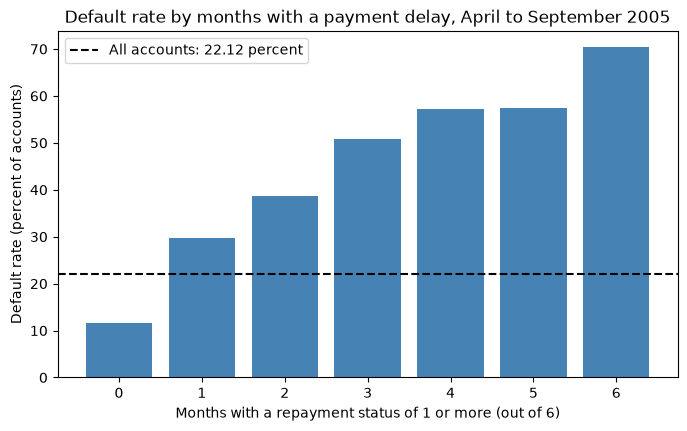

In [46]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(by_months.index, by_months['rate_pct'], color='steelblue')
ax.axhline(overall_rate_pct, color='black', linestyle='--', label='All accounts: 22.12 percent')

ax.legend(loc='upper left')
ax.set_title('Default rate by months with a payment delay, April to September 2005')
ax.set_xlabel('Months with a repayment status of 1 or more (out of 6)')
ax.set_ylabel('Default rate (percent of accounts)')

plt.show()

* One bar is below the dashed line, the accounts with no month of delay, and six are above it. Each bar is at least as tall as the one before.

**Excel side by side.** Each derived column is one formula in a helper column, filled down.

| Job | pandas | Excel, for row 2 | Result |
| --- | --- | --- | --- |
| Utilisation | `cards['BILL_AMT1'] / cards['LIMIT_BAL']` | `=M2 / B2` | 0.196 for the first account |
| Share paid, with no guard | `cards['PAY_AMT1'] / cards['BILL_AMT1']` | `=S2 / M2` | `#DIV/0!` on the 2,008 rows where M is 0 |
| Share paid, bills above zero only | `cards.loc[has_bill, 'PAY_AMT1'] / cards.loc[has_bill, 'BILL_AMT1']` | `=IF(M2 > 0, S2 / M2, "")` | blank on 2,598 rows |
| Median share paid | `cards['share_paid'].median()` | `=MEDIAN(AK2:AK30001)` on that helper column | 0.061 |
| Months with a delay | `(cards[pay_columns] >= 1).sum(axis=1)` | `=COUNTIF(G2:L2, ">=1")` | 2 for the first account |

Where pandas writes `inf` or a missing value and carries on, Excel shows `#DIV/0!` in the cell, and an `AVERAGE` over a range that contains that error returns the error. The `IF` leaves an empty text in the rows with no bill above zero, and `MEDIAN` and `AVERAGE` skip text cells in a range.

**Observations: derived columns**

* Utilisation, the September bill over the limit, has a median of 0.314. The default rate was 16.81 percent in the band above 0 to 0.25 (11,440 accounts) and 30.07 percent in the band above 1 (2,115 accounts). In the band of zero or below it was 24.75 percent (2,598 accounts).
* The share of the September bill paid can be worked out for the 27,402 accounts with a bill above zero. Its median is 0.061. Its mean, 1.776, is carried by a few very large ratios and is not quoted.
* 19,931 accounts had no month with a payment delay, and 11.71 percent of them defaulted. Of the 1,341 accounts with a delay in all six months, 70.32 percent defaulted.

## 7.0 Correlation

### 7.1 The six bills

Q. How closely do the six monthly bills move together? Draw the correlation table as a heatmap.

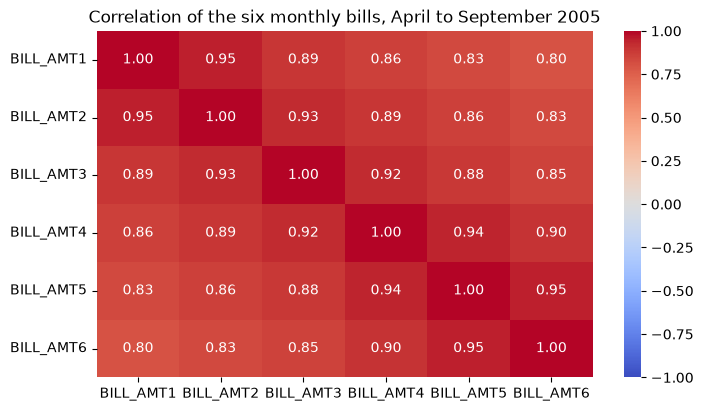

Lowest correlation in the table: 0.8


In [47]:
# the correlation of each pair of the six bill columns
bill_corr = cards[bill_columns].corr()

fig, ax = plt.subplots(figsize=(8, 4.5))

# vmin and vmax fix the colour scale to the full range of a correlation, -1 to 1
sns.heatmap(bill_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation of the six monthly bills, April to September 2005')

plt.show()

print('Lowest correlation in the table:', round(bill_corr.min().min(), 2))

* Every cell is red. The lowest correlation in the table is 0.80, between the September bill and the April bill, five months apart. Bills one month apart are at 0.92 to 0.95.
* An account with a large bill in one month has a large bill in the next. The six columns say nearly the same thing six times.
* That is why this notebook has used one of them, September. A table of default rates by bands of the August bill would look much like one by bands of the September bill, and showing both would count one finding twice.

### 7.2 Correlation with a 0/1 outcome

Q. What is the correlation of each of these columns with the outcome?

In [48]:
# a table of correlations, from which the column for the outcome is taken
columns_to_check = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1', 'utilisation', 'months_delayed', 'default']
with_outcome = cards[columns_to_check].corr()['default']

# leave out the outcome's correlation with itself, which is 1
print(with_outcome.drop('default').round(3))

LIMIT_BAL        -0.154
AGE               0.014
PAY_0             0.325
BILL_AMT1        -0.020
PAY_AMT1         -0.073
utilisation       0.086
months_delayed    0.398
Name: default, dtype: float64


* The largest is 0.398, for the number of months with a delay, then 0.325 for the September status code. The credit limit is at -0.154: the minus sign says that larger limits went with a lower default rate in this file, as section 4.5 found.
* The correlation of age with the outcome is 0.014, the closest to zero in the list.

**Predict 5**

The correlation of age with the outcome is 0.014, almost zero. Does that mean the default rate was about the same in every age band?

> A) yes: a correlation near zero means age and the default rate are unrelated
>
> B) no

Decide, then run the cell.

In [49]:
# the default rate by age band, from section 4.4
print(by_age)

          accounts  defaults  rate_pct
age_band                              
21 to 30     11013      2471     22.44
31 to 40     10713      2189     20.43
41 to 50      6005      1399     23.30
51 to 60      1997       504     25.24
61 to 79       272        73     26.84


* The answer is B. The rate was 22.44 percent in the band 21 to 30, 20.43 percent in the band 31 to 40, and 26.84 percent in the band 61 to 79. That is a range of more than 6 percentage points.
* A correlation measures how well a straight line fits. The rates go down and then up across the age bands, and a straight line fits a dip badly, so the correlation comes out near zero. Notebook 13 met the same thing: one number for the whole table can hide what the groups show.

What a correlation with a 0/1 outcome can and cannot say:

* **It can say** the direction of a straight-line association and give a rough sense of its strength, in one number, for a quick first sort of many columns.
* **It cannot say** what the default rate was in any group. -0.154 does not tell you that the rate went from 31.79 percent to 13.98 percent across the limit bands. The table does.
* **It cannot see** a pattern that is not a straight line, as with age.
* **It treats a code as an amount.** The correlation for `PAY_0` reads -2, -1, 0, 1, 2 as evenly spaced numbers. Two of those codes are not documented, and nothing says they belong in that order.
* **It says nothing about cause.** No correlation in this notebook, and no difference in rates, shows that one thing led to another.

**Excel side by side.**

| Job | pandas | Excel | Result |
| --- | --- | --- | --- |
| Correlation of two bills | `cards['BILL_AMT1'].corr(cards['BILL_AMT2'])` | `=CORREL(M2:M30001, N2:N30001)` | 0.95 |
| Correlation of the limit with the outcome | `cards['LIMIT_BAL'].corr(cards['default'])` | `=CORREL(B2:B30001, Y2:Y30001)` | -0.154 |
| Every pair at once | `cards[bill_columns].corr()` | one `CORREL` for each pair | a 6 by 6 table |
| The colours | `sns.heatmap(bill_corr, annot=True)` | select the table, then Home, Conditional Formatting, Color Scales | |

**Observations: correlation**

* The six monthly bills are correlated at 0.80 or more with each other.
* The correlations with the outcome run from -0.154 for the credit limit to 0.398 for the number of months with a delay. For age it is 0.014, while the default rate by age band ran from 20.43 to 26.84 percent.
* A correlation is a first sort. The rate tables, with their counts, are the findings.

## Summary

**The checks and the decisions**

| Check | Result |
| --- | --- |
| Rows and columns | 30,000 accounts, 25 columns, all whole numbers |
| IDs | unique, 1 to 30,000 |
| Missing values | none |
| Repeated rows | none. 35 rows repeat an earlier row once the ID is left out. Kept. |
| `EDUCATION` codes 0, 5, 6 | not in the documentation. 345 accounts. Kept, labelled `not documented`. |
| `MARRIAGE` code 0 | not in the documentation. 54 accounts. Kept, labelled `not documented`. |
| Repayment status codes -2 and 0 | not in the documentation. 17,496 accounts in September. Kept under their own numbers. A delay is a code of 1 or more. |
| Bills below zero, bills above the limit | 590 and 2,115 in September. The documentation does not explain them. Kept. |
| What was changed | nothing in the file. In the working copy the outcome column is called `default`, and columns were added: three labels, five bands, one status group, and three derived columns. |

**Observations, for the colleague who asked**

The file is the UCI "Default of Credit Card Clients" dataset: 30,000 credit card accounts in Taiwan, with payment records from April to September 2005 and an outcome for the following month. Each line below is a rate in that file with the number of accounts behind it. None is a statement of cause, a statement about any other market, or a basis for a lending decision.

1. **The default rate.** 6,636 of the 30,000 accounts defaulted the following month: 22.12 percent.
2. **Recent repayment status.** Of the 2,667 accounts with a September status of 2, a payment delay of two months, 69.14 percent defaulted. Of the 3,688 with a delay of one month, 33.95 percent. Of the 5,686 with -1, pay duly, 16.78 percent.
3. **Months with a delay.** Of the 19,931 accounts with no month of delay in the six, 11.71 percent defaulted. Of the 1,341 with a delay in all six, 70.32 percent.
4. **Credit limit.** The default rate was 31.79 percent among the 7,676 accounts with a limit of 50,000 NT dollars or less and 13.98 percent among the 7,067 with a limit above 240,000. Within the accounts with a September status of 2, the rate was between 67.5 and 71.1 percent in all four limit bands.
5. **Utilisation.** The rate was 16.81 percent among the 11,440 accounts with a September bill above zero and up to a quarter of the limit, and 30.07 percent among the 2,115 with a bill above the limit.
6. **The demographic columns.** By sex, 24.17 percent (male, 11,888 accounts) and 20.78 percent (female, 18,112). By education, 19.23 percent (graduate school, 10,585), 23.73 percent (university, 14,030), and 25.16 percent (high school, 4,917). By marital status, 23.47 percent (married, 13,659) and 20.93 percent (single, 15,964). By age, 20.43 percent in the band 31 to 40 (10,713) and 26.84 percent in the band 61 to 79 (272). These differences do not explain themselves and are not a basis for treating people differently.
7. **What the documentation leaves open.** 17,496 accounts hold a September status code, -2 or 0, that the documentation does not define. Their default rates were 13.23 percent (code -2, 2,759 accounts) and 12.81 percent (code 0, 14,737 accounts). Any reading of this file depends on what those codes mean, and the dataset page does not say.

**What was new today**

| Job | Code |
| --- | --- |
| A rate from a 0/1 column | `cards['default'].mean()` |
| Rate, with its count, for each group | `cards.groupby(column)['default'].agg(['count', 'sum', 'mean'])` |
| A label for each code | `cards['EDUCATION'].map(education_labels)`, then `.fillna('not documented')` |
| Bands of about equal size | `pd.qcut(cards['LIMIT_BAL'], 4)` |
| A rate for two groupings at once | `pd.pivot_table(cards, values='default', index=..., columns=..., aggfunc='mean')` |
| A count across the columns of each row | `(cards[pay_columns] >= 1).sum(axis=1)` |

**The habits to keep**

* Put the documentation beside `value_counts()`. A value the documentation does not define is kept, counted, and called undocumented. It is not dropped and not explained by a guess.
* Work in a copy, and state each decision.
* The mean of a 0/1 column is a rate, and a rate is shown with its count.
* Compare rates, not counts of defaults.
* Before dividing, look at the denominator. For a ratio, quote the median.
* A difference in rates is an association. It is not a cause, and it is true of this file only.

The next notebook turns from numbers to text.

## Exercises

The exercises use the same file and ask about columns and groupings the lesson did not examine: the August repayment status, the credit limit by outcome and education, sex and marital status together, and the months with no payment. The data is the UCI "Default of Credit Card Clients" dataset by I-Cheng Yeh, CC BY 4.0, as described at the top of this notebook.

Every answer is a rate or a figure in this file, with its count. None is a statement of cause or a statement about people in general.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on and say the unit. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, defines `check`, a small function that marks your answers, and loads `raw` and the working copy `cards`, with the outcome column renamed `default` and the three label columns `sex`, `education`, and `marriage`. It prints the two shapes, (30000, 25) and (30000, 28).

In [50]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# a fresh copy of the file. In Colab it is read from GitHub.
if os.path.exists('../../../data/credit_card_default.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

raw = pd.read_csv(data_folder + 'credit_card_default.csv')

# the working copy of the lesson: the outcome renamed, and the three labels added
cards = raw.copy().rename(columns={'default payment next month': 'default'})
cards['sex'] = cards['SEX'].map({1: 'male', 2: 'female'})
cards['education'] = cards['EDUCATION'].map({1: 'graduate school', 2: 'university', 3: 'high school', 4: 'others'}).fillna('not documented')
cards['marriage'] = cards['MARRIAGE'].map({1: 'married', 2: 'single', 3: 'others'}).fillna('not documented')

print(raw.shape, cards.shape)

(30000, 25) (30000, 28)


### Exercise 1

Q. `PAY_2` is the repayment status in August 2005. Among the accounts with a `PAY_2` of 2, a payment delay of two months, how many accounts are there and what was the default rate in percent, rounded to 2 decimal places? Store the answers in **ex1_accounts** and **ex1_rate**. Print the rate table for every value of `PAY_2`, and say which values are not in the documentation.

In [51]:
ex1_accounts = ...
ex1_rate = ...

In [52]:
check('Exercise 1 accounts', ex1_accounts, 3927)
check('Exercise 1 rate', ex1_rate, 55.61)

Exercise 1 accounts: not attempted yet
Exercise 1 rate: not attempted yet


### Exercise 2

Q. What is the median credit limit, in NT dollars, for each education label? Store the median for `graduate school` in **ex2_graduate** and for `high school` in **ex2_high_school**. Show the number of accounts beside each median.

In [53]:
ex2_graduate = ...
ex2_high_school = ...

In [54]:
check('Exercise 2 graduate school', ex2_graduate, 200000.0)
check('Exercise 2 high school', ex2_high_school, 80000.0)

Exercise 2 graduate school: not attempted yet
Exercise 2 high school: not attempted yet


### Exercise 3

Q. Build a pivot table of the default rate with `marriage` down the side and `sex` across the top, and a second one of the counts. What was the default rate, in percent rounded to 2 decimal places, for the accounts labelled `married` and `male`, and how many accounts is that? Store the answers in **ex3_rate** and **ex3_accounts**. Which cell is the thinnest?

In [55]:
ex3_rate = ...
ex3_accounts = ...

In [56]:
check('Exercise 3 rate', ex3_rate, 25.93)
check('Exercise 3 accounts', ex3_accounts, 5190)

Exercise 3 rate: not attempted yet
Exercise 3 accounts: not attempted yet


### Exercise 4

Q. Build a derived column: for each account, the number of the six months, April to September, in which the amount paid (`PAY_AMT1` to `PAY_AMT6`) was zero. How many accounts paid nothing in all six months, and what was their default rate in percent, rounded to 2 decimal places? Store the answers in **ex4_accounts** and **ex4_rate**. Print the rate table for every count from 0 to 6.

In [57]:
ex4_accounts = ...
ex4_rate = ...

In [58]:
check('Exercise 4 accounts', ex4_accounts, 1432)
check('Exercise 4 rate', ex4_rate, 37.99)

Exercise 4 accounts: not attempted yet
Exercise 4 rate: not attempted yet


### Exercise 5: AI check

You ask an AI assistant for the default rate by education level, with the number of accounts in each level, and the default rate of all the accounts in the table. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it misleads in one way.

Q. Read the code before you run it. How many accounts should the table hold in total, and what should the overall default rate be? The lesson worked both out in section 2.1. Then run the code. Does the answer agree with you?

In [59]:
# written for this course in the style of an AI assistant's answer. It misleads in one way.
# clean up: keep the valid education levels
known = cards[cards['EDUCATION'].isin([1, 2, 3, 4])]

# default rate by education level, in percent
by_level = known.groupby('EDUCATION')['default'].agg(['count', 'mean'])
by_level['mean'] = (by_level['mean'] * 100).round(2)
print(by_level)

ex5_accounts = by_level['count'].sum()
ex5_overall_rate = round(known['default'].mean() * 100, 2)

print('Accounts in the table:', ex5_accounts)
print('Overall default rate:', ex5_overall_rate, 'percent')

           count   mean
EDUCATION              
1          10585  19.23
2          14030  23.73
3           4917  25.16
4            123   5.69
Accounts in the table: 29655
Overall default rate: 22.29 percent


Q. Find the problem and fix the code in the cell above, so that **ex5_accounts** and **ex5_overall_rate** hold the right answers and no account is left out of the table.

In [60]:
check('Exercise 5 accounts', ex5_accounts, 30000)
check('Exercise 5 overall rate', ex5_overall_rate, 22.12)

Exercise 5 accounts: not yet. You have 29655
Exercise 5 overall rate: not yet. You have 22.29
